In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random


In [ ]:

# Loading the cleaned energy dataset
# https://drive.google.com/file/d/1Uv6bKoRF5EfUOkLDWC15Ard2Pc_gasBp/view?usp=sharing
file_path1 = "https://drive.google.com/uc?export=download&id=1Uv6bKoRF5EfUOkLDWC15Ard2Pc_gasBp"
energy_dataset = pd.read_csv(file_path1)

# Setting 'time' column to datetime and making it the index
energy_dataset['time'] = pd.to_datetime(energy_dataset['time'], utc=True)
energy_dataset = energy_dataset.set_index('time') #Setting 'time' column as the index


# Loading weather featuers dataset
# https://drive.google.com/file/d/15lqXcCl8isitrZR5ESSR0VDVupAMqRzq/view?usp=sharing

file_path2 = "https://drive.google.com/uc?export=download&id=15lqXcCl8isitrZR5ESSR0VDVupAMqRzq"
data = pd.read_csv(file_path2)


# PREPROCESSING

In [ ]:
data.shape

(178396, 17)

In [ ]:
data.tail()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
178391,2018-12-31 19:00:00+01:00,Seville,287.76,287.15,288.15,1028,54,3,30,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178392,2018-12-31 20:00:00+01:00,Seville,285.76,285.15,286.15,1029,62,3,30,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178393,2018-12-31 21:00:00+01:00,Seville,285.15,285.15,285.15,1028,58,4,50,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178394,2018-12-31 22:00:00+01:00,Seville,284.15,284.15,284.15,1029,57,4,60,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178395,2018-12-31 23:00:00+01:00,Seville,283.97,282.15,285.15,1029,70,3,50,0.0,0.0,0.0,0,800,clear,sky is clear,01n


**we can see some columns that are not important or give the same data in different ways.**


* we have the column temp, temp_min, temp_max all of them giving almost the same data always.

* there is four columns about weather that have same indication, talking about different stats of the weather.



**Lets investigate these columns more.**

**lets check the values in our dataset**

In [ ]:
data.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00
mean,289.62,288.33,291.09,1069.26,68.42,2.47,166.59,0.08,0.00,0.00,25.07,759.83
std,8.03,7.96,8.61,5969.63,21.90,2.10,116.61,0.40,0.01,0.22,30.77,108.73
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,200.00
25%,283.67,282.48,284.65,1013.00,53.00,1.00,55.00,0.00,0.00,0.00,0.00,800.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,177.00,0.00,0.00,0.00,20.00,800.00
75%,295.15,293.73,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00,801.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00,804.00



1.   All columns have same count so no missing values but we still need to check for duplicated
2.   There is an odd pressure value (max 1008371) which is an abnormal values for a city
3.   temperature looks like its measured in K


## Droping temp columns

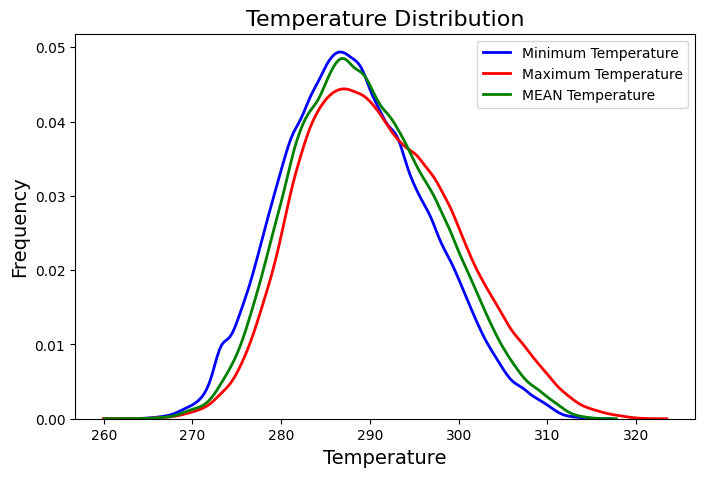

In [ ]:
plt.figure(figsize=(8, 5))


sns.kdeplot(data['temp_min'], color='blue', label='Minimum Temperature', linewidth=2)
sns.kdeplot(data['temp_max'], color='red', label='Maximum Temperature', linewidth=2)
sns.kdeplot(data['temp'], color='green', label='MEAN Temperature', linewidth=2)

plt.title("Temperature Distribution", fontsize=16)
plt.xlabel("Temperature", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.legend()
plt.show()


In [ ]:
data = data.drop(['temp_min','temp_max'], axis=1)

## droping weather columns

In [ ]:
# to know which columns we can drop, we need to know what column gives the most information
# the column with the most amount of details will be the most suitable for us.

# Checking the unique values in each column
weather_id = data['weather_id'].value_counts()
print('weather_id:         ',len(weather_id))

weather_main = data['weather_main'].value_counts()
print('weather_main:       ',len(weather_main))

weather_description = data['weather_description'].value_counts()
print('weather_description:',len(weather_description))

weather_icon = data['weather_icon'].value_counts()
print('weather_icon:       ',len(weather_icon))




weather_id:          38
weather_main:        12
weather_description: 43
weather_icon:        24


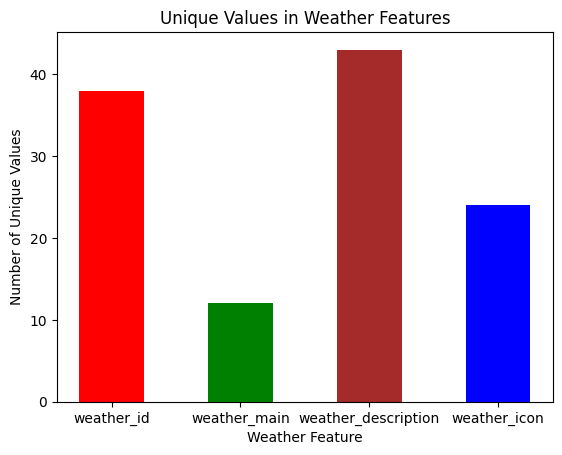

In [ ]:
# x-coordinates of left sides of bars
left = [1, 2, 3, 4]

# heights of bars
height = [len(weather_id), len(weather_main), len(weather_description), len(weather_icon)]

# labels for bars
tick_label = ['weather_id', 'weather_main', 'weather_description', 'weather_icon']

# plotting a bar chart
plt.bar(left, height, tick_label = tick_label,
        width = 0.5, color = ['red', 'green','brown','blue'])

# naming the x-axis
plt.xlabel('Weather Feature')
# naming the y-axis
plt.ylabel('Number of Unique Values')
# plot title
plt.title('Unique Values in Weather Features')

# function to show the plot
plt.show()

**we can see that the best columns are weather_descrition and weather_id, while the worse are weather_main and weather_icon as they don't give as much details.**


In [ ]:
data = data.drop(['weather_id','weather_main','weather_icon','weather_description'], axis=1)

## preprocessing...

In [ ]:
cleaned_data = data

cols = cleaned_data.select_dtypes(include=[np.int64]).columns
for col in cols:
    cleaned_data[col] = cleaned_data[col].values.astype(np.float64)

cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   dt_iso      178396 non-null  object 
 1   city_name   178396 non-null  object 
 2   temp        178396 non-null  float64
 3   pressure    178396 non-null  float64
 4   humidity    178396 non-null  float64
 5   wind_speed  178396 non-null  float64
 6   wind_deg    178396 non-null  float64
 7   rain_1h     178396 non-null  float64
 8   rain_3h     178396 non-null  float64
 9   snow_3h     178396 non-null  float64
 10  clouds_all  178396 non-null  float64
dtypes: float64(9), object(2)
memory usage: 15.0+ MB


<ipython-input-75-e926dd1d0e1f>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=column_types.index.astype(str), y=column_types.values, palette="coolwarm")


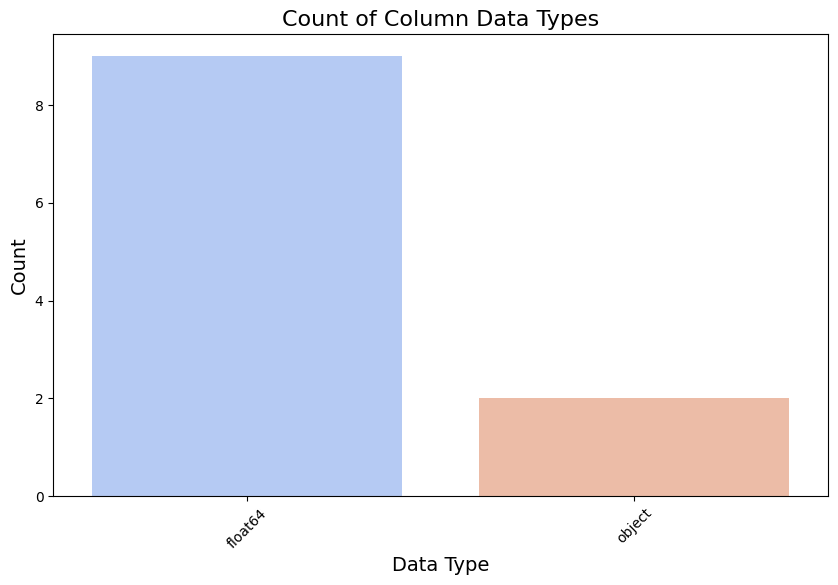

In [ ]:
column_types = cleaned_data.dtypes.value_counts()

# Plotting the data types
plt.figure(figsize=(10, 6))
sns.barplot(x=column_types.index.astype(str), y=column_types.values, palette="coolwarm")
plt.title("Count of Column Data Types", fontsize=16)
plt.xlabel("Data Type", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Checking unique values in the column 'column_name'
unique_counts = cleaned_data['city_name'].value_counts()
print(unique_counts)


city_name
Madrid        36267
Bilbao        35951
Seville       35557
 Barcelona    35476
Valencia      35145
Name: count, dtype: int64


<ipython-input-77-85fa24d98913>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette="viridis")


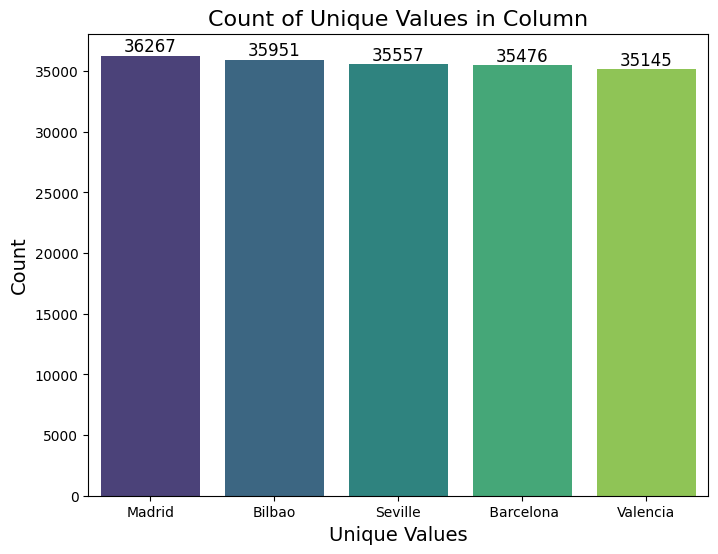

In [ ]:
"""
as we can see, the dataset mainly consists of 5 cities, each having 35k rows, making it have
almost the same amount of rows as the other dataset. Now we need to fix this so we can merge
our datasets, into one dataset with 35k rows.
"""
plt.figure(figsize=(8, 6))

sns.barplot(x=unique_counts.index, y=unique_counts.values, palette="viridis")
plt.title("Count of Unique Values in Column", fontsize=16)
plt.xlabel("Unique Values", fontsize=14)
plt.ylabel("Count", fontsize=14)

# count for each city
for i, value in enumerate(unique_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom', fontsize=12, color='black')

plt.show()

In [ ]:
# Before spliting lets make the time an index and drop duplicated rows with same values in both time and city name
cleaned_data['time'] = pd.to_datetime(cleaned_data['dt_iso'], utc=True, infer_datetime_format=True)
cleaned_data = cleaned_data.drop_duplicates(subset=['time', 'city_name'])

# Convert dt_iso to datetime type, renaming it and settimh it as index
cleaned_data = cleaned_data.drop(['dt_iso'], axis=1)
cleaned_data = cleaned_data.set_index('time')

cleaned_data.shape

<ipython-input-78-a6cc6bc710d6>:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  cleaned_data['time'] = pd.to_datetime(cleaned_data['dt_iso'], utc=True, infer_datetime_format=True)


(175320, 10)

<ipython-input-79-22b0a8510868>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette="viridis")


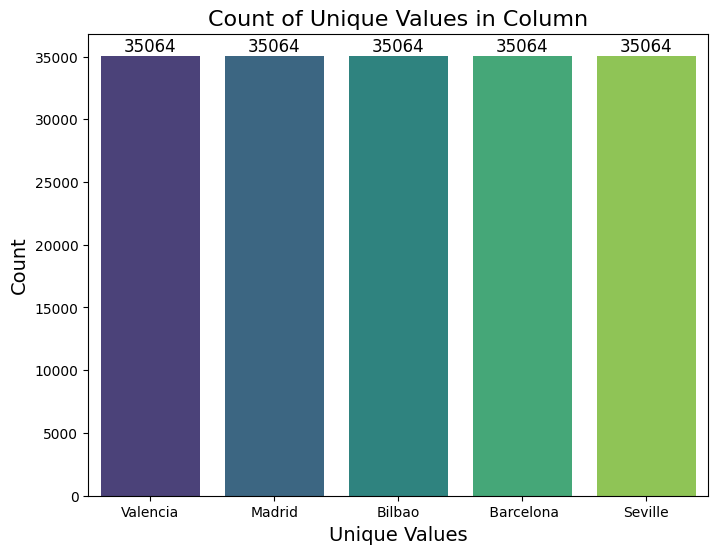

In [ ]:
unique_counts = cleaned_data['city_name'].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(x=unique_counts.index, y=unique_counts.values, palette="viridis")
plt.title("Count of Unique Values in Column", fontsize=16)
plt.xlabel("Unique Values", fontsize=14)
plt.ylabel("Count", fontsize=14)

# count for each city
for i, value in enumerate(unique_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom', fontsize=12, color='black')

plt.show()

## Removing abnormal values from Pressure.

**We start with the abnormal pressure value**

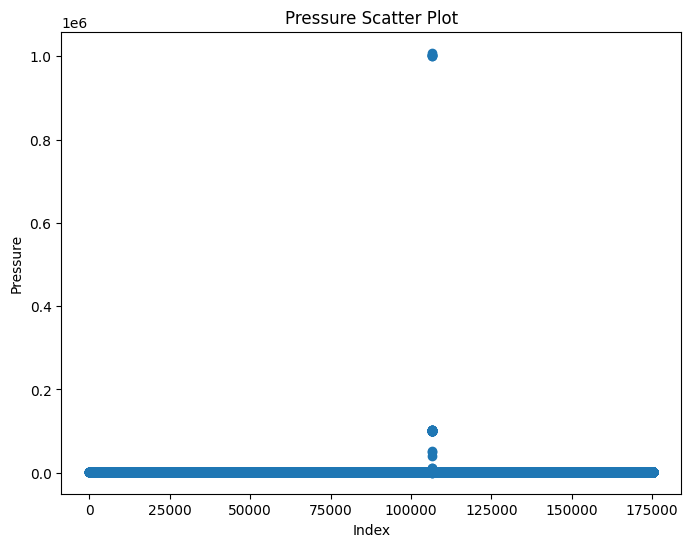

In [ ]:
# Plotting the scatter plot for 'pressure' column
plt.figure(figsize=(8, 6))
plt.scatter(range(len(cleaned_data['pressure'])), cleaned_data['pressure'])

# Title and labels
plt.title('Pressure Scatter Plot')
plt.xlabel('Index')
plt.ylabel('Pressure')

plt.show()

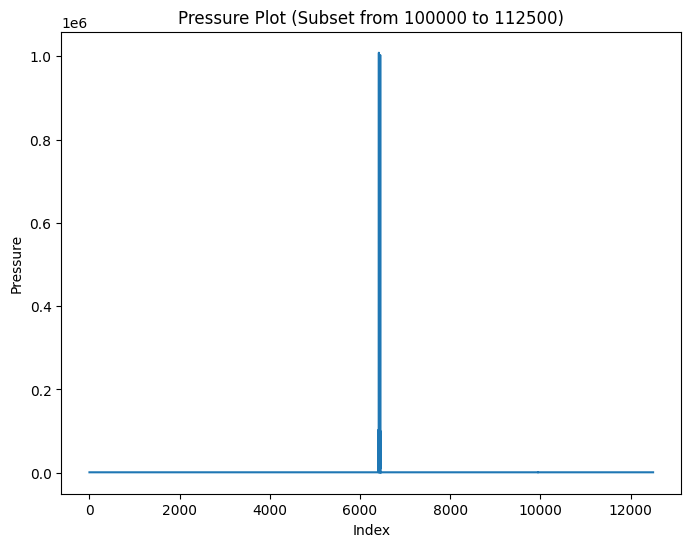

In [ ]:
# Subsetting the data for the range between index 100000 and 150000 (data points)
subset_data = cleaned_data['pressure'][100000:112500]


plt.figure(figsize=(8, 6))
plt.plot(range(len(subset_data)), subset_data)

plt.title('Pressure Plot (Subset from 100000 to 112500)')
plt.xlabel('Index')
plt.ylabel('Pressure')

plt.show()

In [ ]:
# Replacing outliers in 'pressure' with NaNs
cleaned_data.loc[cleaned_data.pressure > 1051, 'pressure'] = np.nan
cleaned_data.loc[cleaned_data.pressure < 931, 'pressure'] = np.nan

# Displaying the rows with null values
erm = cleaned_data[cleaned_data.isnull().any(axis=1)]

erm

,city_name,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
time,,,,,,,,,,
2016-07-21 19:00:00+00:00,Valencia,298.94,NaN,41.0,3.0,107.0,0.0,0.0,0.0,0.0
2016-08-03 15:00:00+00:00,Valencia,308.34,NaN,46.0,1.0,292.0,0.0,0.0,0.0,32.0
2016-08-03 16:00:00+00:00,Valencia,305.31,NaN,45.0,1.0,315.0,0.0,0.0,0.0,8.0
2016-08-03 17:00:00+00:00,Valencia,304.55,NaN,47.0,0.0,180.0,0.0,0.0,0.0,20.0
2016-08-03 18:00:00+00:00,Valencia,302.94,NaN,47.0,1.0,135.0,0.0,0.0,0.0,20.0
...,...,...,...,...,...,...,...,...,...,...
2015-06-10 02:00:00+00:00,Barcelona,293.34,NaN,11.0,1.0,7.0,0.0,0.0,0.0,24.0
2015-06-25 09:00:00+00:00,Barcelona,298.70,NaN,10.0,4.0,66.0,0.0,0.0,0.0,0.0
2015-06-28 01:00:00+00:00,Barcelona,294.81,NaN,29.0,1.0,218.0,0.0,0.0,0.0,0.0


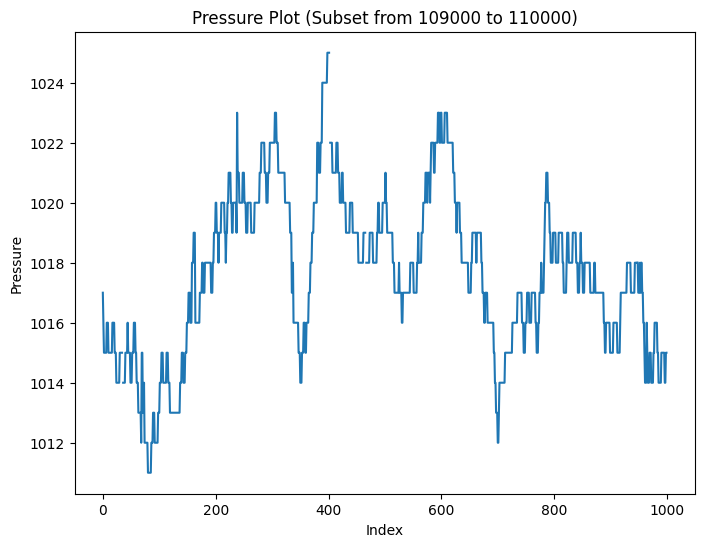

In [ ]:
#cleaned_data.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

# Subsetting the data for the range between index 100000 and 150000
subset_data = cleaned_data['pressure'][109000:110000]

plt.figure(figsize=(8, 6))
plt.plot(range(len(subset_data)), subset_data)

plt.title('Pressure Plot (Subset from 109000 to 110000)')
plt.xlabel('Index')
plt.ylabel('Pressure')

plt.show()

<ipython-input-84-31434b3e6b84>:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  cleaned_data.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)


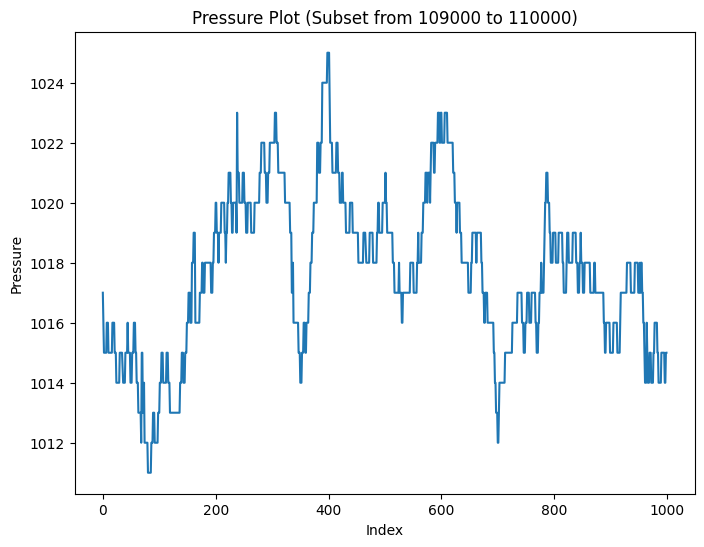

In [ ]:
cleaned_data.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

# Subsetting the data for the range between index 100000 and 150000
subset_data = cleaned_data['pressure'][109000:110000]

plt.figure(figsize=(8, 6))
plt.plot(range(len(subset_data)), subset_data)

plt.title('Pressure Plot (Subset from 109000 to 110000)')
plt.xlabel('Index')
plt.ylabel('Pressure')

plt.show()

looks much better.

## Splitting the dataset

In [ ]:
Madriddb = cleaned_data[cleaned_data.city_name.str.contains('Madrid')]
Bilbaodb = cleaned_data[cleaned_data.city_name.str.contains('Bilbao')]
Sevilledb = cleaned_data[cleaned_data.city_name.str.contains('Seville')]
Barcelonadb = cleaned_data[cleaned_data.city_name.str.contains('Barcelona')]
Valenciadb = cleaned_data[cleaned_data.city_name.str.contains('Valencia')]

print("Madrid   ",Madriddb.shape)
print("Bilbao   ",Bilbaodb.shape)
print("Seville  ",Sevilledb.shape)
print("Barcelona",Barcelonadb.shape)
print("Valencia ",Valenciadb.shape)

Madrid    (35064, 10)
Bilbao    (35064, 10)
Seville   (35064, 10)
Barcelona (35064, 10)
Valencia  (35064, 10)


In [ ]:
# Perfect
Valenciadb.head()


,city_name,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
time,,,,,,,,,,
2014-12-31 23:00:00+00:00,Valencia,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,Valencia,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,Valencia,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00+00:00,Valencia,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00+00:00,Valencia,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0


**The datasets now are cleaned and ready to be merged**

## MERGING THE DATASETS

Merging all the 6 datasets

In [ ]:
datasets = [Madriddb, Bilbaodb, Sevilledb, Barcelonadb, Valenciadb]

final_dataset = energy_dataset


for df in datasets:
    city = df['city_name'].unique()
    city_str = str(city).replace("'", "").replace('[', '').replace(']', '').replace(' ', '')
    df = df.add_suffix('_{}'.format(city_str))
    final_dataset = final_dataset.merge(df, on=['time'], how='outer')
    final_dataset = final_dataset.drop('city_name_{}'.format(city_str), axis=1)

final_dataset.shape

(35064, 62)

# Bivariate EDA :

comparing and understanding relationship between relevant columns


In [ ]:
final_dataset.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,...,clouds_all_Barcelona,temp_Valencia,pressure_Valencia,humidity_Valencia,wind_speed_Valencia,wind_deg_Valencia,rain_1h_Valencia,rain_3h_Valencia,snow_3h_Valencia,clouds_all_Valencia
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,...,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.0,35064.00,35064.00
mean,383.53,448.09,5622.71,4256.55,298.34,475.56,972.21,2605.50,6263.50,60.23,...,22.71,290.78,1015.27,65.09,2.69,160.80,0.03,0.0,0.00,20.74
std,85.35,354.62,2201.56,1961.97,52.52,792.29,400.71,1835.07,840.24,20.24,...,27.33,7.23,10.04,19.68,2.58,120.41,0.26,0.0,0.01,25.60
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,268.83,969.00,8.00,0.00,0.00,0.00,0.0,0.00,0.00
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1078.00,5759.00,53.00,...,0.00,285.15,1012.00,51.00,1.00,50.00,0.00,0.0,0.00,0.00
50%,367.00,509.00,4969.50,4475.00,300.00,68.00,906.00,2165.00,6564.00,57.00,...,20.00,290.19,1017.00,67.00,2.00,130.00,0.00,0.0,0.00,20.00
75%,433.00,757.00,6429.00,5839.00,330.00,616.00,1250.00,3757.25,7025.00,80.00,...,36.00,296.15,1021.00,82.00,4.00,280.00,0.00,0.0,0.00,20.00
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,...,100.00,311.15,1042.00,100.00,133.00,360.00,12.00,0.1,1.12,100.00


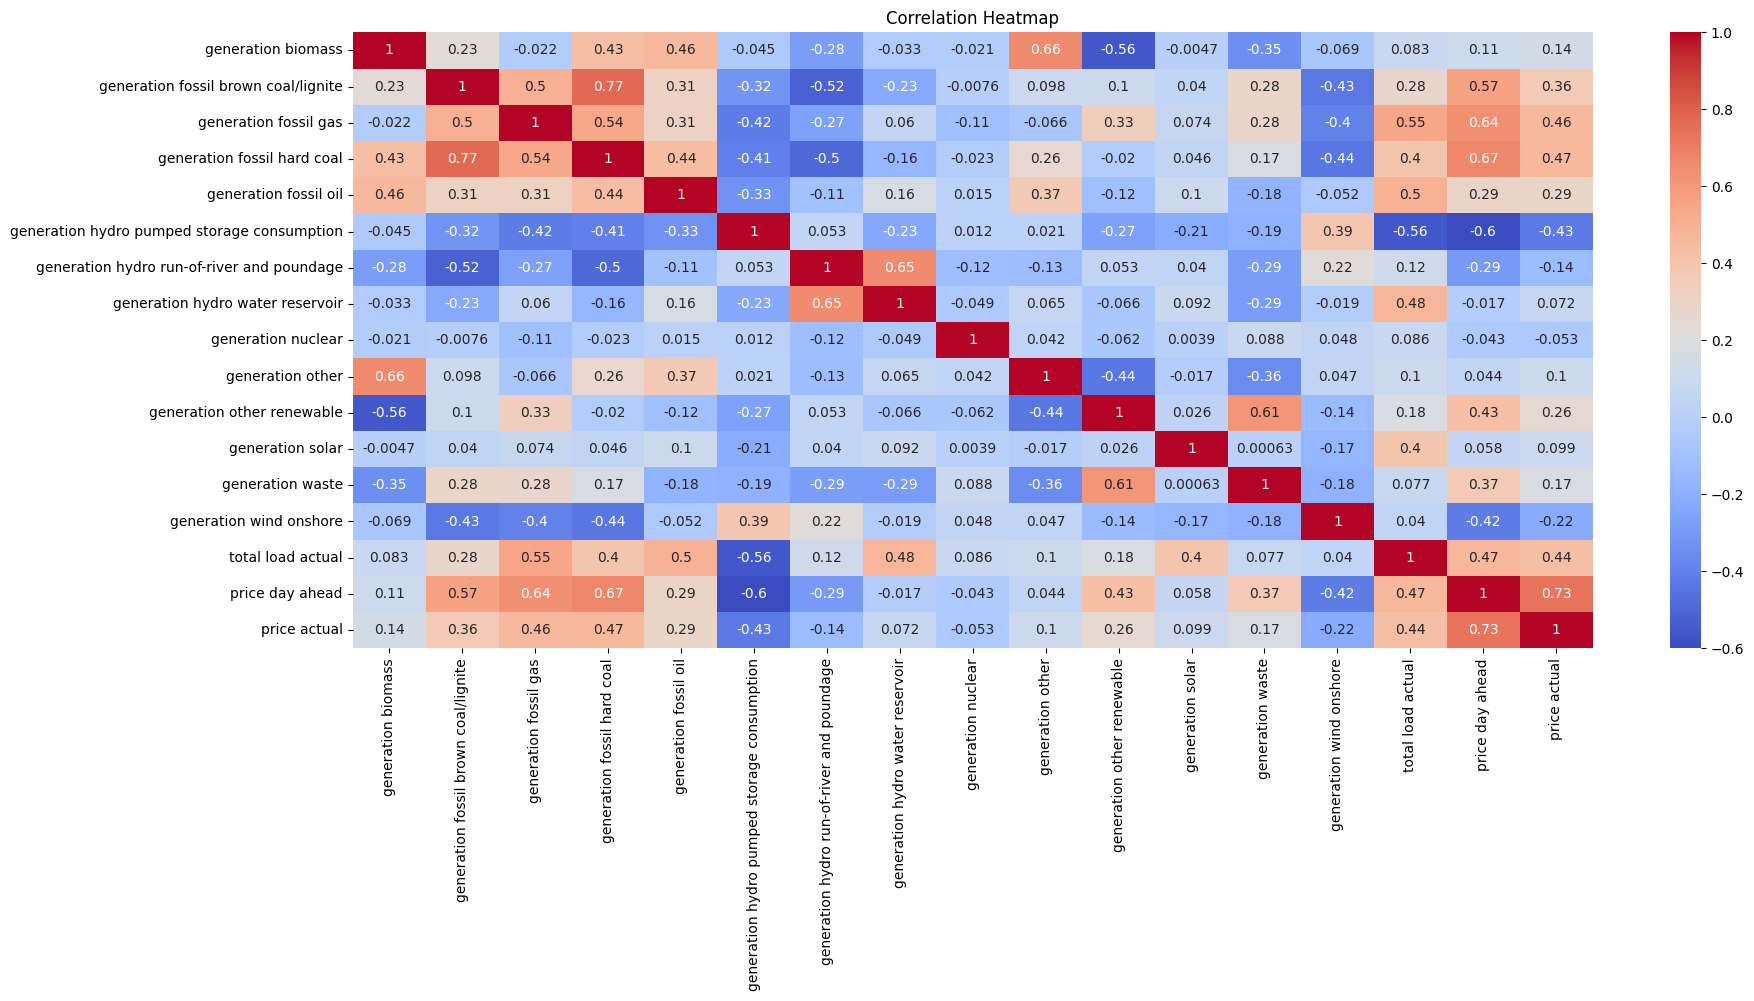

In [ ]:
correlation_matrix = energy_dataset.corr()

# Plotting the correlation_matrix
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


For the **total load**, we can see that it corelates the most with **generation using fossil gas**, meaning that its the biggest contributer to the Spainy load.

the biggest feature that is affecting the price is generation of load using hard coal, meaning that its the most expensive method (not too much ahead of fossile gas, both in cost and right behind it in load generation), the interesting ones are load generation using hydro water resevoirs and using solar panels, that give an important load, while not effecting the price.

In [ ]:
final_dataset.to_csv('final_dataset.csv')

from google.colab import files


# Seasonality and trend analysis:

Look for seasonality.

peak demand daily (hours, and seasonaly)

**Extracting the dates**

In [ ]:
# Avoiding using the original dataset
data = final_dataset.copy()

# Extracting date and time components
data['date'] = data.index.date
data['hour'] = data.index.hour
data['week'] = data.index.isocalendar().week
data['month'] = data.index.month

# Getting 5 random unique dates
random_dates = random.sample(list(data['date'].unique()), 5)
random_weeks = random.sample(list(data['week'].unique()), 5)
random_months = random.sample(list(data['month'].unique()), 5)

# Filtering data for the selected dates
filtered_data = data[data['date'].isin(random_dates)]
filtered_week_data = data[data['week'].isin(random_weeks)]
filtered_month_data = data[data['month'].isin(random_months)]



Plotting daily seasonality/trends investigation

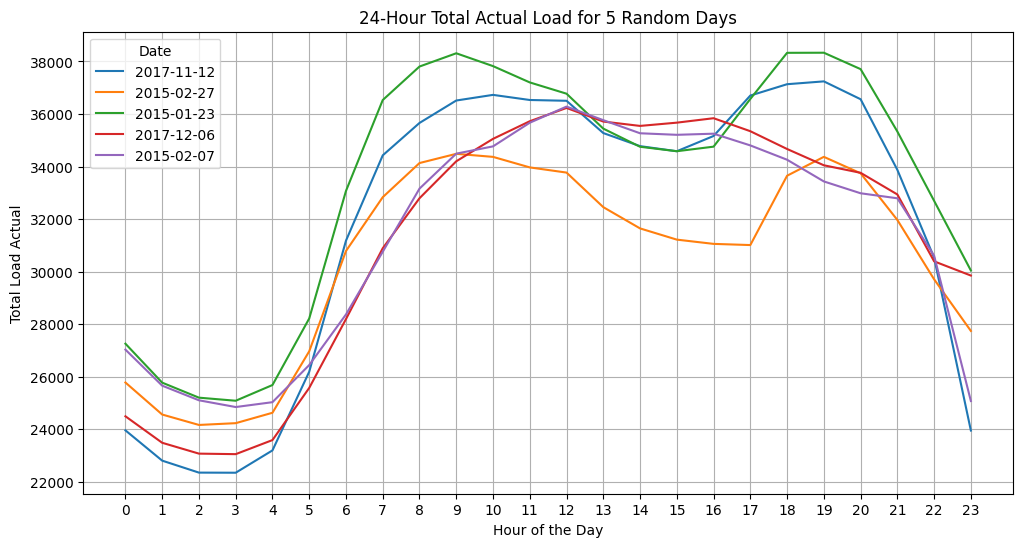

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
for date in random_dates:
    daily_data = filtered_data[filtered_data['date'] == date]
    # Specifiying the column
    plt.plot(daily_data['hour'], daily_data['total load actual'], label=str(date))


plt.title('24-Hour Total Actual Load for 5 Random Days')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Load Actual')
plt.xticks(range(0, 24))
plt.legend(title="Date")
plt.grid(True)
plt.show()

**Investigating weekly seasonality and trends**

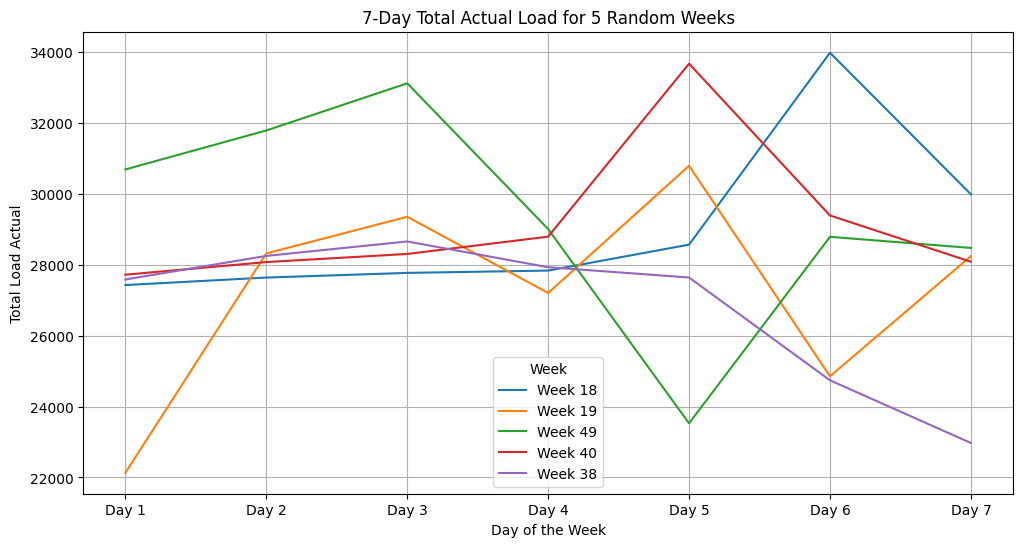

In [ ]:
# Filtering exactly 7 days for each random week
plt.figure(figsize=(12, 6))
for week in random_weeks:
    weekly_data = filtered_week_data[filtered_week_data['week'] == week]
    # Getting the first 7 unique dates of the week
    unique_dates = weekly_data['date'].unique()[:7]
    daily_weekly_data = weekly_data[weekly_data['date'].isin(unique_dates)].groupby('date')['total load actual'].mean()
    plt.plot(range(1, len(daily_weekly_data) + 1), daily_weekly_data, label=f"Week {week}")

plt.title('7-Day Total Actual Load for 5 Random Weeks')
plt.xlabel('Day of the Week')
plt.ylabel('Total Load Actual')
plt.xticks(range(1, 8), labels=[f"Day {i}" for i in range(1, 8)])
plt.legend(title="Week")
plt.grid(True)
plt.show()


**investigating monthly seasonality and trends**

<ipython-input-94-2a5a4047eb90>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_data['date'] = pd.to_datetime(monthly_data['date'])
<ipython-input-94-2a5a4047eb90>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_data['date'] = pd.to_datetime(monthly_data['date'])
<ipython-input-94-2a5a4047eb90>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

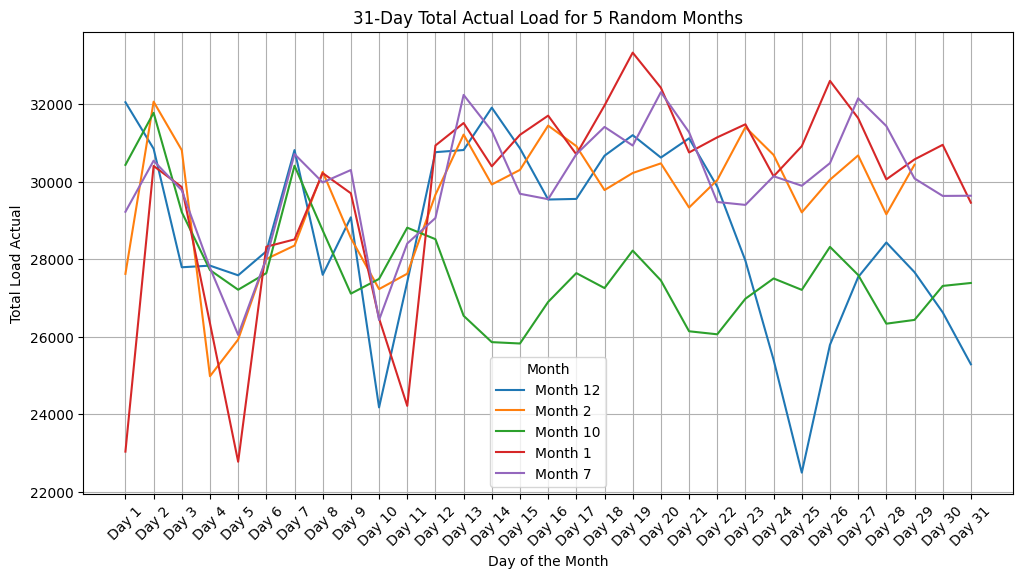

In [ ]:
plt.figure(figsize=(12, 6))
for month in random_months:
    monthly_data = filtered_month_data[filtered_month_data['month'] == month]
    monthly_data['date'] = pd.to_datetime(monthly_data['date'])
    daily_monthly_data = monthly_data.groupby(monthly_data['date'].dt.day)['total load actual'].mean()
    plt.plot(range(1, len(daily_monthly_data) + 1), daily_monthly_data, label=f"Month {month}")

plt.title('31-Day Total Actual Load for 5 Random Months')
plt.xlabel('Day of the Month')
plt.ylabel('Total Load Actual')
plt.xticks(range(1, 32), labels=[f"Day {i}" for i in range(1, 32)], rotation=45)
plt.legend(title="Month")
plt.grid(True)
plt.show()